# 06 비디오 OCR — AI Hub 한글 Scene Text · PaddleOCR

**05 VLM 비디오 요약**에서 추출한 대표 프레임(또는 현장 이미지)에 **PaddleOCR(pretrained)** 로 텍스트 **검출·인식**을 적용합니다. 별도 CRNN 학습 없이 사전학습 모델만 사용합니다.

| Part | 주제 |
|------|------|
| 1 | AI Hub JSON 라벨 & **AI_Hub_한글_OCR** 데이터셋 준비 |
| 2 | 텍스트 **검출(Detection)** — GT · IoU · Morphology proposal(비교) |
| 3 | **PaddleOCR** 검출·인식 · GT 대비 CER 평가 |
| 4 | 통합 OCR 파이프라인 — manifest · IPAD 프레임 적용(선택) |

### OCR이란?

**OCR(Optical Character Recognition, 광학 문자 인식)** 은 이미지·영상 속 **글자의 위치를 찾고(Detection), 무슨 글자인지 읽는(Recognition)** 기술입니다.

```
이미지/프레임
    ↓ Detection  — "글자가 어디에 있나?" (bbox 사각형)
    ↓ Recognition — "무슨 글자인가?" (한글·숫자 문자열)
    ↓ 결과 — bbox + 텍스트 + (선택) 신뢰도
```

영상 OCR은 **프레임마다 2D OCR을 반복**하는 것입니다. 05번 VLM 요약과 달리, **좌표·정확한 문자열**이 필요할 때 OCR 엔진을 씁니다.

### AI_Hub_한글_OCR 실습 데이터

1. [AI Hub](https://aihub.or.kr)에서 **한글 OCR** 다운로드
2. 노트북과 **같은 폴더**에 `AI_Hub_한글_OCR.zip` 배치
3. 실행 시 `AI_Hub_한글_OCR.zip` → **`AI_Hub_한글_OCR/`** 자동 압축 해제
4. zip 내부: `01.원천데이터/.../*.jpg`, `02.라벨링데이터/.../*.json`

> **인코딩:** zip cp949 파일명 복원 · JSON utf-8/cp949 · 이미지 `np.fromfile`+`imdecode`

> **PaddleOCR 설치 (최초 1회):** `pip install paddlepaddle==2.6.2 paddleocr==2.9.1`  
> 노트북 커널 Python에 설치: `import sys; !{sys.executable} -m pip install ...`  
> GPU는 [PaddlePaddle 설치 가이드](https://www.paddlepaddle.org.cn/install/quick) 참고


### 본 실습에서 다루는 기술

| 기법 | 한 줄 설명 | 코드에서의 역할 |
|------|-----------|----------------|
| **AI Hub JSON** | bbox + text 라벨 | `parse_aihub_json`, `TextBox` |
| **Polygon IoU** | 검출 품질 평가 | `polygon_iou`, `evaluate_detection` |
| **Morphology Proposal** | OpenCV 베이스라인 검출(비교) | `propose_text_regions` |
| **PaddleOCR** | 사전학습 det+rec | `get_paddle_ocr`, `run_paddle_ocr` |
| **CER** | Character Error Rate | `compute_cer` |
| **OCR Pipeline** | 검출→인식→JSON | `run_ocr_pipeline`, `export_ocr_manifest` |
| **Video Frame OCR** | IPAD 프레임 OCR | `_find_ipad_frames` (선택) |

핵심: 영상 OCR은 **프레임 단위 2D OCR**을 시간축에 적용하는 것입니다.

#### 용어·기술 상세 (쉬운 설명)

| 용어 | 쉬운 설명 |
|------|-----------|
| **Scene Text** | 책 스캔이 아니라 **간판·표지판·HMI·문서 사진**처럼 현장 배경에 있는 글자 |
| **Detection (검출)** | 이미지에서 **글자 영역(bbox)** 만 찾기. "어디에 글자가 있나?" |
| **Recognition (인식)** | 잘린 글자 영역에서 **실제 문자열** 읽기. "무슨 글자인가?" |
| **bbox / wordbox** | 글자를 감싸는 **사각형 좌표** (x, y, 너비, 높이) |
| **GT (Ground Truth)** | 사람이标注한 **정답 라벨** — AI Hub JSON의 bbox + text |
| **IoU** | 두 사각형이 **얼마나 겹치는지** 0~1. 1에 가까울수록 위치가 정확 |
| **Precision / Recall / F1** | 검출 품질 지표. Precision=허위 alarm 적음, Recall=놓친 글자 적음 |
| **Morphology** | OpenCV로 **이진화·닫기(close)** 연산 — 글자 덩어리를 contour로 찾는 전통 방식 |
| **PaddleOCR** | Baidu 오픈소스 OCR. **수백만 장으로 이미 학습된** det+rec 모델 제공 |
| **CER** | Character Error Rate. 정답 대비 **틀린 글자 비율**. 0=완벽, 1=전부 틀림 |
| **manifest** | 이미지별 OCR 결과를 모아 둔 **JSON 목록** — 다른 프로그램·알람과 연동용 |
| **pretrained** | 우리가 직접 학습하지 않고 **이미 학습된 weight**를 그대로 사용 |


In [1]:
# ── 패키지 설치 (최초 1회, 주석 해제 후 실행) ──
# 노트북 커널과 동일 Python에 설치: import sys; !{sys.executable} -m pip install ...
# WinError 5(cv2.pyd) → 커널 종료 후 터미널에서 설치

# !pip install -q -r requirements.txt

# CPU: !pip install paddlepaddle==2.6.2 paddleocr==2.9.1
# !py -3.11 -m pip install paddlepaddle==2.6.2 paddleocr==2.9.1

# GPU: https://www.paddlepaddle.org.cn/install/quick 에서 CUDA 버전에 맞게 paddlepaddle 설치 후 paddleocr
# ! python -m pip install paddlepaddle-gpu==3.3.1 -i https://www.paddlepaddle.org.cn/packages/stable/cu129/

In [2]:
from __future__ import annotations

# =============================================================================
# 환경 설정 — import, AI_Hub_한글_OCR/출력 경로, OCR 하이퍼파라미터, 한글 폰트
# =============================================================================

# --- 표준 라이브러리 ---
import json
import os
import platform
import random
import subprocess
import textwrap
import zipfile
from dataclasses import dataclass
from pathlib import Path

# --- 영상·수치·시각화 ---
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch  # CUDA 사용 가능 여부 → PADDLE_USE_GPU
from matplotlib.gridspec import GridSpec
from PIL import Image

# ── AI Hub 한글 OCR — zip 해제·데이터 루트 (한글 경로) ───────────────────────
# zip 파일명 후보 — 대소문자·언더스코어 변형 허용
AIHUB_ZIP_NAMES = ("AI_Hub_한글_OCR.zip", "AI_hub_한글_OCR.zip", "ai_hub_한글_ocr.zip")
AIHUB_EXTRACT_DIR = Path("AI_Hub_한글_OCR")          # zip 해제 및 데이터 읽기 루트
AIHUB_SEARCH_PATHS = [AIHUB_EXTRACT_DIR]             # 이 경로에서만 OCR 데이터 로드

# 분석 산출물 저장 경로
OUTPUT_DIR = Path("output_ocr_kr")
FIG_DIR = OUTPUT_DIR / "figures"
CROP_DIR = OUTPUT_DIR / "crops"
PRED_DIR = OUTPUT_DIR / "predictions"
MANIFEST_PATH = OUTPUT_DIR / "ocr_manifest.json"

# 데이터·OCR 파라미터
MAX_TRAIN_IMAGES = 300     # 실습 속도용 train 이미지 상한 (None=전체)
MAX_TEST_IMAGES = 80       # test 이미지 상한
DET_IOU_THRESH = 0.5        # 검출 평가 IoU 임계값

# PaddleOCR (사전학습 — 학습 없음)
PADDLE_LANG = "korean"              # 한글+영문 혼합 문서
PADDLE_USE_GPU = torch.cuda.is_available()
PADDLE_USE_ANGLE_CLS = True         # 기울어진 텍스트 보정
PADDLE_DET_THRESH = 0.3             # 검출 confidence 하한
PADDLE_REC_THRESH = 0.5             # 인식 confidence 하한
PADDLE_MAX_OCR_SAMPLES = 6          # Part 3 시각화·CER 평가 이미지 수
PADDLE_PIPELINE_SAMPLES = 3          # Part 4 manifest 샘플 수

# IPAD 프레임 OCR (선택 — 05와 동일 zip 사용)
RUN_IPAD_FRAMES = True
IPAD_ZIP_NAMES = ("IPAD_sample.zip", "IPAD_Sample.zip")
IPAD_SEARCH_PATHS = [Path("IPAD_Sample"), Path("IPAD_sample")]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RNG = random.Random(42)  # 재현 가능한 split/shuffle

# figures/crops/predictions 하위 폴더 생성
# figures/crops/predictions 하위 폴더 생성
for d in (OUTPUT_DIR, FIG_DIR, CROP_DIR, PRED_DIR):
    d.mkdir(parents=True, exist_ok=True)



# Colab 여부 — 폰트 apt-get 분기
def is_running_in_colab() -> bool:
    """Google Colab 런타임 여부 — 한글 폰트 apt 설치 분기용."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def setup_matplotlib_korean() -> None:
    """matplotlib 한글·마이너스 기호 깨짐 방지."""
    from matplotlib import font_manager
    if is_running_in_colab():
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-nanum"],
            check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        font_manager._load_fontmanager(try_read_cache=False)
    if platform.system() == "Windows":
        candidates = ["Malgun Gothic", "NanumGothic", "Gulim"]
        fallback = Path(os.environ.get("WINDIR", r"C:\Windows")) / "Fonts" / "malgun.ttf"
    elif platform.system() == "Darwin":
        candidates = ["AppleGothic", "Apple SD Gothic Neo"]
        fallback = None
    else:
        candidates = ["NanumGothic", "NanumBarunGothic"]
        fallback = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((n for n in candidates if n in available), None)
    if chosen:
        plt.rcParams["font.family"] = chosen
    elif fallback and fallback.exists():
        font_manager.fontManager.addfont(str(fallback))
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(fallback)).get_name()
    plt.rcParams["axes.unicode_minus"] = False


setup_matplotlib_korean()
print(f"환경 설정 완료 | device={DEVICE}")

환경 설정 완료 | device=cuda


In [3]:
# =============================================================================
# AI Hub 한글 OCR 데이터 로드 · JSON 파싱 · train/test split
# =============================================================================

# 지원 이미지 확장자 — rglob 탐색 시 필터
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
# 경로 문자열에 포함되면 train split으로 분류
TRAIN_KEYWORDS = ("train", "training", "학습", "traning", "원천")
# 경로 문자열에 포함되면 test split으로 분류
TEST_KEYWORDS = ("valid", "validation", "test", "검증", "testing")
# 라벨에서 제외할 더미/무시 텍스트
SKIP_TEXT = {"###", "xxx", "dontcare", "don't care", "dont care"}


@dataclass

# GT 한 단어(또는 구)의 4점 bbox + 정답 문자열
class TextBox:
    """AI Hub bbox GT — 4점 사각형(축 정렬) + transcription."""
    quad: np.ndarray
    text: str

    @property
    def axis_aligned_rect(self) -> tuple[int, int, int, int]:
        xs, ys = self.quad[:, 0], self.quad[:, 1]
        return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())


@dataclass

# 이미지 1장 + 해당 GT 박스 목록 + train/test 구분
class OcrSample:
    image_path: Path
    boxes: list[TextBox]
    split: str
    json_path: Path | None = None


@dataclass

# OCR 파이프라인 최종 출력 — manifest JSON 직렬화용
class OcrPipelineResult:
    image_path: str
    detections: list[dict]
    full_text: str
    method: str



# zip/데이터 탐색 시작 경로 — cwd, 노트북 InputDir 등
def _search_roots() -> list[Path]:
    roots = [Path(".").resolve(), Path.cwd().resolve()]
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip and hasattr(ip, "config"):
            cfg = ip.config.get("InteractiveShell", {}).get("InputDir", "")
            if cfg:
                roots.append(Path(cfg).resolve())
    except Exception:
        pass
    out: list[Path] = []
    for r in roots:
        if r not in out:
            out.append(r)
    return out



# root 하위 json 또는 이미지 파일 목록 (정렬)
def _iter_data_files(root: Path, pattern: str) -> list[Path]:
    if not root.is_dir():
        return []
    if pattern == "json":
        return sorted(root.rglob("*.json"))
    return sorted(p for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS)



# json·jpg가 모두 존재하면 유효한 AI Hub 루트
def _is_valid_aihub_root(base: Path) -> bool:
    if not base.is_dir():
        return False
    return len(_iter_data_files(base, "json")) > 0 and len(_iter_data_files(base, "img")) > 0



# 프로젝트 폴더에서 AI_Hub_한글_OCR.zip 탐색
def find_aihub_zip() -> Path | None:
    for search in _search_roots():
        for name in AIHUB_ZIP_NAMES:
            p = search / name
            if p.is_file():
                return p
        try:
            for f in search.iterdir():
                if f.is_file() and f.suffix.lower() == ".zip" and "한글" in f.stem and "ocr" in f.stem.lower():
                    return f
        except OSError:
            continue
    return None


def _decode_zip_filename(raw_name: str, flag_bits: int = 0) -> str:
    """
    AI Hub zip 한글 파일명 복원.
    Windows에서 만든 zip은 파일명을 CP949 바이트로 저장하는데,
    Python zipfile은 기본 cp437로 읽어 '╣┤≤...' 같은 깨진 이름이 됩니다.
    → cp437로 되돌린 뒤 cp949로 디코딩하면 '라벨링데이터' 등 정상 복원.
    """
    if not raw_name:
        return raw_name
    if flag_bits & 0x800:
        return raw_name
    for enc in ("cp949", "euc-kr"):
        try:
            return raw_name.encode("cp437").decode(enc)
        except (UnicodeDecodeError, UnicodeEncodeError):
            continue
    return raw_name



# extractall 대신 멤버별 추출 — cp949 파일명 복원
def _extract_aihub_zip(zpath: Path) -> Path:
    """AI_Hub_한글_OCR.zip → AI_Hub_한글_OCR/ (cp949 파일명 복원)."""
    import shutil

    AIHUB_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zpath, "r") as zf:
        # 멤버별 수동 추출 — extractall()은 cp437 파일명 깨짐 유발
        for member in zf.infolist():
            rel = _decode_zip_filename(member.filename, member.flag_bits).replace("\\", "/")  # cp949 복원
            if not rel:
                continue
            parts = [p for p in rel.split("/") if p]
            if not parts:
                continue
            # zip 최상위가 AI_Hub_한글_OCR 래퍼면 한 단계 제거
            if parts[0].lower() == AIHUB_EXTRACT_DIR.name.lower():
                parts = parts[1:]
            if not parts:
                continue
            out_path = AIHUB_EXTRACT_DIR.joinpath(*parts)
            if member.is_dir() or rel.endswith("/"):
                out_path.mkdir(parents=True, exist_ok=True)
                continue
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with zf.open(member, "r") as src, open(out_path, "wb") as dst:
                shutil.copyfileobj(src, dst)

    return AIHUB_EXTRACT_DIR



# 이전에 cp437로 잘못 풀린 ╣┤≤ 폴더 정리
def _cleanup_garbled_extract(parent: Path) -> None:
    """cp437 깨짐으로 생긴 ╣┤≤ 형태 폴더·잘못 풀린 데이터 정리."""
    import shutil

    garbled_markers = ("╣", "┤", "≤", "║", "°", "├", "─", "═")
    for child in list(parent.iterdir()):
        if not child.is_dir() or child.name == AIHUB_EXTRACT_DIR.name:
            continue
        if child.name.startswith("output_"):
            continue
        if any(m in child.name for m in garbled_markers):
            safe = child.name.encode("unicode_escape").decode("ascii")
            print(f"[AI Hub OCR] 깨진 폴더 삭제: {safe}")
            shutil.rmtree(child, ignore_errors=True)



# zip → AI_Hub_한글_OCR/ 준비 후 경로 반환
def ensure_aihub_ocr_dataset() -> Path:
    """AI_Hub_한글_OCR.zip → AI_Hub_한글_OCR/ 압축 해제 후 해당 경로만 사용."""
    if _is_valid_aihub_root(AIHUB_EXTRACT_DIR):
        print(f"[AI Hub OCR] 데이터 사용: {AIHUB_EXTRACT_DIR.resolve()}")
        return AIHUB_EXTRACT_DIR.resolve()

    zpath = find_aihub_zip()
    if zpath is not None:
        _cleanup_garbled_extract(Path(".").resolve())
        print(f"[AI Hub OCR] {zpath.name} → {AIHUB_EXTRACT_DIR}/ 압축 해제 (cp949 파일명)")
        _extract_aihub_zip(zpath)
        if _is_valid_aihub_root(AIHUB_EXTRACT_DIR):
            print(f"[AI Hub OCR] 데이터 준비 완료: {AIHUB_EXTRACT_DIR.resolve()}")
            return AIHUB_EXTRACT_DIR.resolve()

    raise FileNotFoundError(
        "AI Hub 한글 OCR 데이터를 찾을 수 없습니다.\n"
        f"  1) {AIHUB_ZIP_NAMES[0]} 을 노트북 폴더에 배치\n"
        f"  2) 자동 해제 → {AIHUB_EXTRACT_DIR}/\n"
        "  3) 기존에 한글이 깨진 폴더(╣┤≤...)가 있으면 삭제 후 셀 재실행\n"
        f"  zip: {zpath or '없음'}"
    )



# Windows 한글 경로 + utf-8/cp949 인코딩 fallback
def _read_json_file(path: Path) -> dict:
    raw = np.fromfile(str(path), dtype=np.uint8)
    for enc in ("utf-8-sig", "utf-8", "cp949"):
        try:
            data = json.loads(raw.tobytes().decode(enc))
            if isinstance(data, dict):
                return data
        except (UnicodeDecodeError, json.JSONDecodeError):
            continue
    raise ValueError(f"JSON 파싱 실패: {path}")



# (x,y,w,h) → 4꼭짓점 numpy 배열
def bbox_xywh_to_quad(x: float, y: float, w: float, h: float) -> np.ndarray:
    x1, y1, x2, y2 = int(x), int(y), int(x + w), int(y + h)
    return np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=np.int32)



# AI Hub JSON bbox 다양한 포맷(dict/list/8점) 통합 파싱
def _parse_bbox_value(raw) -> tuple[float, float, float, float] | None:
    if raw is None:
        return None
    if isinstance(raw, dict):
        if all(k in raw for k in ("x", "y", "width", "height")):
            return float(raw["x"]), float(raw["y"]), float(raw["width"]), float(raw["height"])
        if all(k in raw for k in ("left", "top", "width", "height")):
            return float(raw["left"]), float(raw["top"]), float(raw["width"]), float(raw["height"])
        return None
    if isinstance(raw, (list, tuple)):
        nums = [float(v) for v in raw]
        if len(nums) == 4:
            x, y, a, b = nums
            if a > x and b > y:
                return x, y, a - x, b - y
            return x, y, a, b
        if len(nums) == 8:
            xs, ys = nums[0::2], nums[1::2]
            x0, y0 = min(xs), min(ys)
            return x0, y0, max(xs) - x0, max(ys) - y0
    return None



# LabelMe 등 polygon points → 축 정렬 quad
def _points_to_quad(points) -> np.ndarray | None:
    if not points:
        return None
    try:
        arr = np.array(points, dtype=np.float32).reshape(-1, 2)
    except (ValueError, TypeError):
        return None
    if arr.shape[0] < 2:
        return None
    xs, ys = arr[:, 0], arr[:, 1]
    return bbox_xywh_to_quad(xs.min(), ys.min(), xs.max() - xs.min(), ys.max() - ys.min())



# 공백·SKIP_TEXT 제거 후 유효 라벨만 반환
def _normalize_text(text: str) -> str | None:
    t = str(text).strip()
    if not t or t.lower() in SKIP_TEXT:
        return None
    return t



# AI Hub text.word[] 항목 → TextBox
def _word_entry_to_box(entry: dict) -> TextBox | None:
    text = _normalize_text(entry.get("value") or entry.get("text") or "")
    if text is None:
        return None
    bbox = _parse_bbox_value(entry.get("wordbox") or entry.get("bbox"))
    if bbox is None:
        return None
    return TextBox(quad=bbox_xywh_to_quad(*bbox), text=text)



# COCO/ICDAR 형식 annotation → TextBox
def _annotation_to_box(ann: dict) -> TextBox | None:
    text = _normalize_text(
        ann.get("text") or ann.get("transcription") or ann.get("label") or ann.get("value") or ""
    )
    if text is None:
        return None
    bbox = _parse_bbox_value(ann.get("bbox") or ann.get("wordbox"))
    if bbox is not None:
        return TextBox(quad=bbox_xywh_to_quad(*bbox), text=text)
    quad = _points_to_quad(ann.get("points"))
    if quad is None:
        return None
    return TextBox(quad=quad, text=text)



# AI Hub 인쇄체 OCR JSON — word[] / annotations[] / shapes[] 지원
def parse_aihub_json(data: dict) -> tuple[str | None, list[TextBox]]:
    boxes: list[TextBox] = []
    image_name: str | None = None

    if isinstance(data.get("image"), dict):
        image_name = data["image"].get("file_name") or data["image"].get("filename")

    text_block = data.get("text")
    if isinstance(text_block, dict):
        words = text_block.get("word") or text_block.get("words") or []  # AI Hub 인쇄체 형식
        for entry in words:
            if isinstance(entry, dict):
                box = _word_entry_to_box(entry)
                if box:
                    boxes.append(box)
        if boxes:
            return image_name, boxes

    if "images" in data and "annotations" in data:
        for ann in data.get("annotations", []):
            box = _annotation_to_box(ann)
            if box:
                boxes.append(box)
        return image_name, boxes

    image_name = image_name or data.get("imagePath") or data.get("file_name")
    for ann in data.get("annotations") or []:
        box = _annotation_to_box(ann)
        if box:
            boxes.append(box)
    for shape in data.get("shapes", []):
        text = _normalize_text(shape.get("text") or shape.get("label") or "")
        quad = _points_to_quad(shape.get("points"))
        if text and quad is not None:
            boxes.append(TextBox(quad=quad, text=text))
    return image_name, boxes



# stem(확장자 제외) → 이미지 Path 매핑
def _index_images(root: Path) -> dict[str, Path]:
    return {p.stem.lower(): p for p in _iter_data_files(root, "img")}



# json 파일명·image.file_name으로 짝 이미지 찾기
def _resolve_image(json_path: Path, image_name: str | None, img_index: dict[str, Path]) -> Path | None:
    candidates = [json_path.stem.lower()]
    if image_name:
        candidates.insert(0, Path(image_name).stem.lower())
    for stem in candidates:
        if stem in img_index:
            return img_index[stem]
    if image_name:
        target = Path(image_name).name.lower()
        for p in img_index.values():
            if p.name.lower() == target:
                return p
    return None



# 폴더명(train/test/원천/검증)으로 split 추론
def _path_split_hint(path: Path) -> str | None:
    joined = "/".join(p.lower() for p in path.parts)
    if any(k in joined for k in TEST_KEYWORDS):
        return "test"
    if any(k in joined for k in TRAIN_KEYWORDS):
        return "train"
    return None



# 폴더 힌트 없을 때 hash 기반 80/20 split
def _assign_flat_split(json_path: Path) -> str:
    return "test" if hash(json_path.stem) % 100 < 20 else "train"



# 전체 json 순회 → OcrSample train/test 리스트 생성
def load_aihub_dataset(root: Path) -> tuple[list[OcrSample], list[OcrSample]]:
    img_index = _index_images(root)
    train_samples: list[OcrSample] = []
    test_samples: list[OcrSample] = []
    seen: set[str] = set()

    for json_path in _iter_data_files(root, "json"):  # 라벨 json 1파일 = 이미지 1장
        if any(skip in json_path.name.lower() for skip in ("meta", "license", "info")):  # 메타 json 스킵
            continue
        try:
            data = _read_json_file(json_path)
        except (ValueError, OSError):
            continue
        image_name, boxes = parse_aihub_json(data)
        if not boxes:
            continue
        img_path = _resolve_image(json_path, image_name, img_index)
        if img_path is None:
            continue
        key = img_path.stem.lower()
        if key in seen:  # 동일 이미지 중복 라벨 방지
            continue
        seen.add(key)
        split = _path_split_hint(json_path) or _path_split_hint(img_path) or _assign_flat_split(json_path)
        sample = OcrSample(img_path, boxes, split, json_path)
        (test_samples if split == "test" else train_samples).append(sample)

    # test 폴더가 없으면 train에서 20% hold-out
    if not test_samples and len(train_samples) > 20:
        n = max(1, len(train_samples) // 5)
        test_samples, train_samples = train_samples[-n:], train_samples[:-n]

    if MAX_TRAIN_IMAGES is not None:
        train_samples = train_samples[:MAX_TRAIN_IMAGES]
    if MAX_TEST_IMAGES is not None:
        test_samples = test_samples[:MAX_TEST_IMAGES]
    return train_samples, test_samples



# cv2.imread 대신 np.fromfile+imdecode — Windows 한글 경로 대응
def read_image_bgr(path: Path) -> np.ndarray:
    buf = np.fromfile(str(path), dtype=np.uint8)  # 한글 경로 bytes 읽기
    img = cv2.imdecode(buf, cv2.IMREAD_COLOR)  # BGR ndarray 디코딩
    if img is None:
        raise FileNotFoundError(f"이미지를 읽을 수 없습니다: {path}")
    return img

## Part 1 — AI Hub 한글 OCR 데이터셋

AI Hub zip을 풀고, JSON 라벨에서 **글자 위치(GT bbox)** 와 **정답 텍스트**를 읽어 `OcrSample` 리스트로 만듭니다.

| 용어 | 설명 |
|------|------|
| **Scene Text** | 간판·라벨·HMI·문서 촬영 등 **자연/현장 배경**의 텍스트 |
| **AI Hub JSON** | `text.word[]` — 각 단어마다 `wordbox` [x,y,w,h] + `value`(한글) |
| **원천데이터 / 라벨링데이터** | jpg(이미지)와 json(라벨)이 **별도 폴더**에 있는 AI Hub 구조 |
| **TextBox** | 코드 내부 표현 — 4점 quad + transcription 문자열 |
| **train / test split** | 폴더명(원천·검증) 또는 hash로 학습·평가용 분리 |
| **Don't care (`xxx`)** | 읽을 필요 없는 영역 — 평가·학습에서 제외 |

> **한 줄 요약:** AI Hub JSON bbox를 `TextBox`로 변환하고, GT를 초록 박스로 그려 데이터가 올바른지 확인합니다.


[AI Hub OCR] 데이터 사용: C:\MyCursorLab\08_Video AI 처리 및 분석\AI_Hub_한글_OCR
AI Hub root : C:\MyCursorLab\08_Video AI 처리 및 분석\AI_Hub_한글_OCR
train=300장 | test=80장
예시: 00110011001.jpg | 박스=70 | 텍스트=['■', '【서식', '83】']


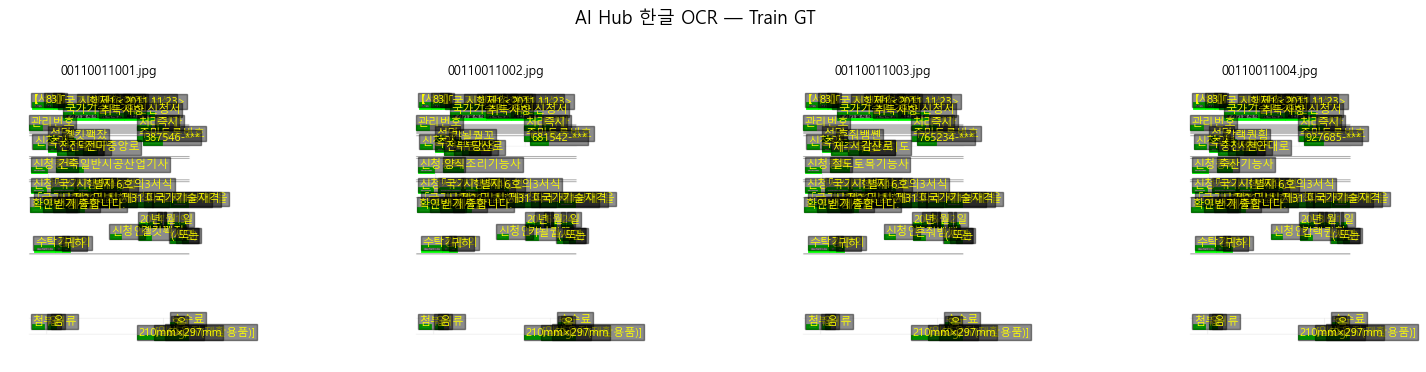

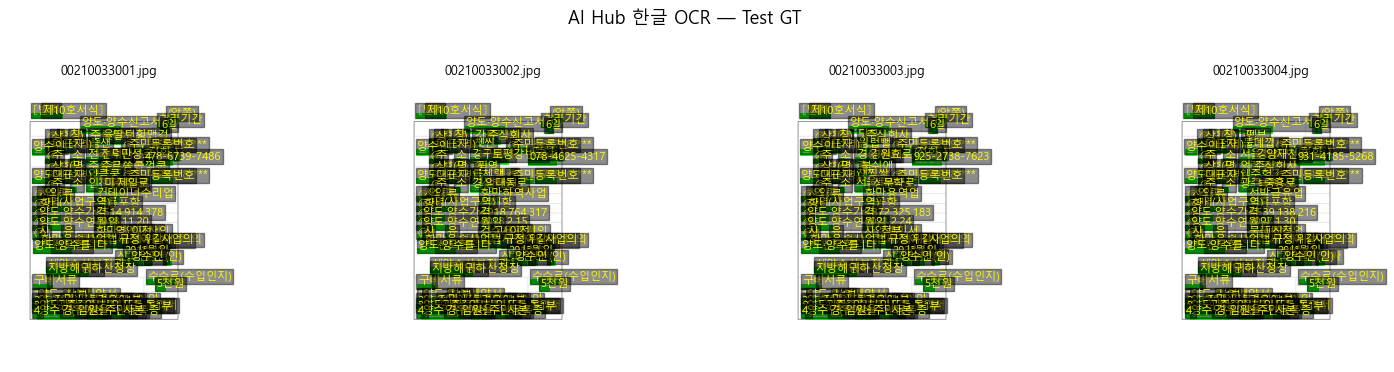

In [4]:
# ── Part 1: AI Hub 데이터셋 로드 & GT 시각화 ──
# ensure_aihub_ocr_dataset → load_aihub_dataset 순으로 GT 샘플 준비


# zip 해제(필요 시) + AI_Hub_한글_OCR/ 루트 확보
AIHUB_ROOT = ensure_aihub_ocr_dataset()
TRAIN_SAMPLES, TEST_SAMPLES = load_aihub_dataset(AIHUB_ROOT)  # json→OcrSample 리스트

print(f"AI Hub root : {AIHUB_ROOT.resolve()}")
print(f"train={len(TRAIN_SAMPLES)}장 | test={len(TEST_SAMPLES)}장")
if TRAIN_SAMPLES:
    ex = TRAIN_SAMPLES[0]
    print(f"예시: {ex.image_path.name} | 박스={len(ex.boxes)} | 텍스트={[b.text for b in ex.boxes[:3]]}")



# GT bbox(초록) + transcription(노란 라벨)을 이미지 위에 그려 PNG 저장
def plot_ocr_samples(samples: list[OcrSample], title: str, save_path: Path, max_show: int = 4) -> None:
    """AI Hub GT bbox + transcription 오버레이."""
    n = min(max_show, len(samples))  # 최대 max_show장까지만 가로 배열

    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.6))
    if n == 1:
        axes = [axes]
    for ax, sample in zip(axes, samples[:n]):
        img = read_image_bgr(sample.image_path)
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(rgb)
        for box in sample.boxes:  # AI Hub wordbox GT

            ax.add_patch(mpatches.Polygon(box.quad, fill=False, edgecolor="lime", linewidth=2))
            x0, y0 = box.quad[0]
            ax.text(x0, max(0, y0 - 4), box.text, color="yellow", fontsize=8,
                    bbox=dict(facecolor="black", alpha=0.45, pad=1))
        ax.set_title(sample.image_path.name, fontsize=9)
        ax.axis("off")
    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()


plot_ocr_samples(TRAIN_SAMPLES, "AI Hub 한글 OCR — Train GT", FIG_DIR / "01_train_gt_overlay.png")
plot_ocr_samples(TEST_SAMPLES, "AI Hub 한글 OCR — Test GT", FIG_DIR / "01_test_gt_overlay.png")

> **📖 Part 1 결과 해석 (초보자용)**
>
> ### 콘솔 출력
> | 메시지 | 의미 |
> |--------|------|
> | `[AI Hub OCR] 데이터 사용: ...` | zip 이미 풀려 있거나, 방금 `AI_Hub_한글_OCR/`에 해제 완료 |
> | `train=N장 \| test=M장` | 학습·평가용 이미지 샘플 수 (`MAX_TRAIN_IMAGES` 등으로 상한) |
> | `박스=70 \| 텍스트=['...']` | 한 장에 word bbox가 몇 개인지, 앞 3개 정답 문자열 미리보기 |
>
> ### GT 시각화 그래프 (`01_train_gt_overlay.png`)
> | 요소 | 의미 |
> |------|------|
> | **초록 polygon** | AI Hub JSON **정답 bbox** (wordbox) |
> | **노란 라벨** | 해당 영역의 **정답 텍스트** |
>
> 💡 GT가 이미지와 맞게 그려지면 **데이터 로드·인코딩·경로**는 정상입니다. zip cp949 깨짐 폴더(`╣┤≤...`)가 있으면 setup 셀의 `_cleanup_garbled_extract`가 삭제합니다.


## Part 2 — 텍스트 검출(Detection) · Morphology Proposal

**Detection만** 다룹니다 — "글자가 어디 있는가?" OpenCV **전통 방식**으로 후보 bbox를 만들고, GT와 **IoU**로 품질을 숫자로 봅니다.

| 구성 | 설명 |
|------|------|
| **GT bbox** | AI Hub JSON `wordbox` — 평가 기준(정답) |
| **Proposal** | 그레이스케일 → adaptive threshold → morphology → contour → bbox |
| **IoU** | proposal bbox vs GT bbox **겹침 비율** — 0.5 이상이면 "맞춤" |
| **Precision** | proposal 중 GT와 맞은 비율 — **허위 검출**이 적을수록 높음 |
| **Recall** | GT 중 proposal이 잡은 비율 — **놓친 글자**가 적을수록 높음 |
| **F1** | Precision과 Recall의 조화 평균 |

> OpenCV proposal은 **교육용 베이스라인**입니다. 복잡한 한글 문서에서는 F1이 낮을 수 있습니다. Part 3 **PaddleOCR** pretrained 검출과 품질을 비교합니다.


Detection (proposal) | P=0.000 R=0.000 F1=0.000 (IoU≥0.5)


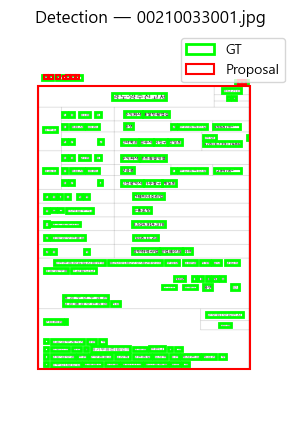

In [5]:
# ── Part 2: 텍스트 검출 · IoU 평가 ──
# OpenCV morphology proposal — PaddleOCR 대비 교육용 베이스라인



def polygon_area(poly: np.ndarray) -> float:
    """Shoelace formula — 4점 이상 다각형 면적."""
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def polygon_iou(poly_a: np.ndarray, poly_b: np.ndarray) -> float:
    """OpenCV intersectConvexConvex로 두 볼록 다각형 IoU."""
    area_a = polygon_area(poly_a)
    area_b = polygon_area(poly_b)
    if area_a <= 0 or area_b <= 0:
        return 0.0
    inter_area, _ = cv2.intersectConvexConvex(
        poly_a.astype(np.float32), poly_b.astype(np.float32)
    )
    union = area_a + area_b - inter_area
    return float(inter_area / union) if union > 0 else 0.0


def rect_to_quad(x1: int, y1: int, x2: int, y2: int) -> np.ndarray:
    """axis-aligned bbox → 4점 quad."""
    return np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=np.int32)



# adaptive threshold + morphology → 텍스트 후보 bbox (x1,y1,x2,y2)
def propose_text_regions(image_bgr: np.ndarray) -> list[tuple[int, int, int, int]]:
    """
    간단한 텍스트 proposal — 그레이스케일 + adaptive threshold + morphology.
    AI Hub 현장 간판·표지 이미지에서 동작하는 교육용 베이스라인.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)  # 컬러 → 그레이

    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    # 국소 밝기 차이로 글자(어두운 부분) 분리
    bw = cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 21, 10
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    morph = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel, iterations=2)  # 흩어진 획 연결

    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = gray.shape
    proposals: list[tuple[int, int, int, int]] = []
    for cnt in contours:
        x, y, bw_, bh_ = cv2.boundingRect(cnt)
        area = bw_ * bh_
        # 너무 작은 노이즈·너무 큰 배경 제거
        if area < 400 or bw_ < 20 or bh_ < 12:

            continue
        if bw_ > w * 0.95 and bh_ > h * 0.95:
            continue
        aspect = bw_ / max(bh_, 1)
        if aspect > 20 or aspect < 0.05:
            continue
        proposals.append((x, y, x + bw_, y + bh_))
    return proposals



# proposal vs GT wordbox — TP/FP/FN 집계 후 P/R/F1
def evaluate_detection(samples: list[OcrSample], iou_thresh: float = DET_IOU_THRESH) -> dict:
    """GT 대비 proposal 검출 Precision / Recall / F1."""
    tp = fp = fn = 0
    for sample in samples:
        img = read_image_bgr(sample.image_path)
        props = propose_text_regions(img)
        gt_quads = [b.quad for b in sample.boxes]
        matched_gt = set()  # 이미 매칭된 GT index — 중복 TP 방지

        for x1, y1, x2, y2 in props:
            pred_quad = rect_to_quad(x1, y1, x2, y2)
            best_iou, best_j = 0.0, -1
            for j, gt in enumerate(gt_quads):
                iou = polygon_iou(pred_quad, gt)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= iou_thresh and best_j not in matched_gt:
                tp += 1
                matched_gt.add(best_j)
            else:
                fp += 1
        fn += len(gt_quads) - len(matched_gt)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1}



# GT(초록 polygon) vs Proposal(빨간 rect) 한 장 비교
def plot_detection_result(sample: OcrSample, save_path: Path) -> None:
    """GT(초록) vs Proposal(빨강) 비교."""
    img = read_image_bgr(sample.image_path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    props = propose_text_regions(img)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.imshow(rgb)
    for box in sample.boxes:
        ax.add_patch(mpatches.Polygon(box.quad, fill=False, edgecolor="lime", linewidth=2, label="GT"))
    for x1, y1, x2, y2 in props:
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=1.5, label="Proposal"))
    ax.set_title(f"Detection — {sample.image_path.name}")
    ax.axis("off")
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper right")
    fig.tight_layout()
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()


det_metrics = evaluate_detection(TEST_SAMPLES)
print(
    f"Detection (proposal) | P={det_metrics['precision']:.3f} "
    f"R={det_metrics['recall']:.3f} F1={det_metrics['f1']:.3f} "
    f"(IoU≥{DET_IOU_THRESH})"
)
if TEST_SAMPLES:
    plot_detection_result(TEST_SAMPLES[0], FIG_DIR / "02_detection_proposal.png")

> **📖 Part 2 결과 해석 (초보자용)**
>
> ### 콘솔 출력 예
> `Detection (proposal) | P=0.000 R=0.000 F1=0.000 (IoU≥0.5)`
>
> | 지표 | 읽는 법 |
> |------|---------|
> | **P (Precision)** | 빨간 proposal 중 **GT와 겹치는 것** 비율. 0이면 대부분 엉뚱한 위치 |
> | **R (Recall)** | 초록 GT 중 **proposal이 잡은** 비율. 0이면 글자를 거의 못 찾음 |
> | **F1** | P·R 종합. **0.3 이상**이면 baseline으로 쓸 만함, 문서 OCR은 PaddleOCR 권장 |
>
> ### Detection 그래프 (`02_detection_proposal.png`)
> | 색 | 의미 |
> |----|------|
> | **초록** | GT (정답 위치) |
> | **빨강** | OpenCV proposal (알고리즘이 추측한 위치) |
>
> 💡 proposal F1이 낮아도 **정상**입니다. Morphology는 조명·배경에 민감하고, Part 3 PaddleOCR이 실무 검출·인식을 담당합니다.


## Part 3 — PaddleOCR 검출·인식 (pretrained)

**Detection + Recognition** 을 **한 번에** 수행합니다. 직접 CRNN을 학습하지 않고, 대규모 데이터로 **이미 학습된** PaddleOCR weight를 사용합니다.

| 구성 | 설명 |
|------|------|
| **Detection (DB 등)** | 딥러닝으로 텍스트 **영역 polygon/bbox** 탐지 |
| **Angle Classifier** | 기울어진 글자 **방향 보정** (선택) |
| **Recognition (CRNN/SVTR)** | crop된 영역에서 **한글·숫자 문자열** 출력 |
| **confidence** | 모델이 결과에 대해 부여하는 **신뢰도** 0~1 |
| **CER** | GT 문자열 vs PaddleOCR 문자열 **글자 단위 오류율** |

> CRNN+CTC 직접 학습 대신 **PaddleOCR** pretrained를 사용합니다. **첫 실행 시** 한글 det/rec 모델 weight가 자동 다운로드됩니다 (수백 MB, 수 분 소요).


PaddleOCR 준비 | lang=korean | gpu=True
PaddleOCR vs GT | images=6 | matched=524/793 | CER=0.627
샘플 00210033001.jpg | PaddleOCR regions=102
  [별지 (conf=1.00)
  [yHY흑이LIY (conf=0.72)
  앞쪽 (conf=1.00)
  처리기 (conf=1.00)
  간 (conf=1.00)
  양도양수신고서 (conf=0.98)
  등9 (conf=0.95)
  0상 (conf=0.93)


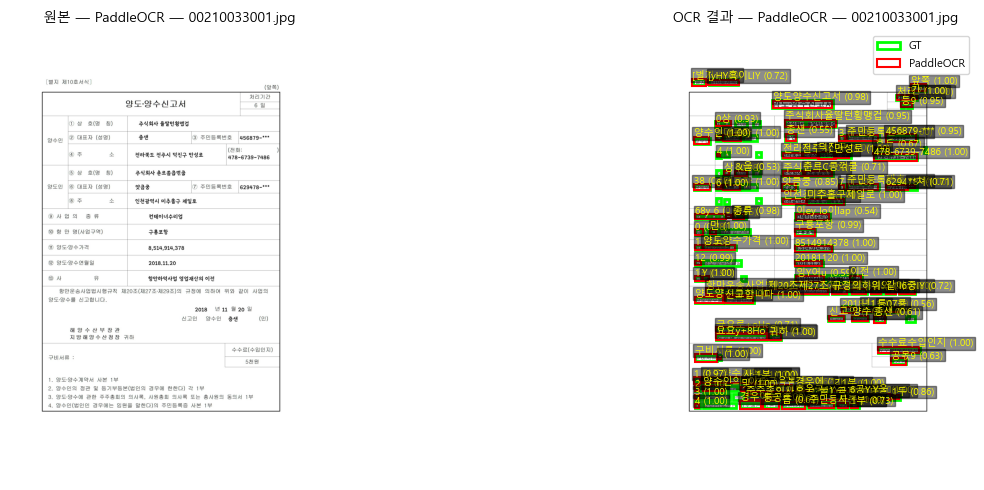

In [6]:
# ── Part 3: PaddleOCR 검출·인식 (학습 없음) ──
# 사전학습 모델로 det+rec — CRNN 직접 학습 없음


# 전역 싱글톤 — 모델 weight 1회만 로드 (수 GB, 수십 초 소요)
_PADDLE_OCR = None


def get_paddle_ocr():
    """PaddleOCR Reader 싱글톤 — 최초 1회 모델 로드."""
    global _PADDLE_OCR
    if _PADDLE_OCR is not None:
        return _PADDLE_OCR
    try:
        from paddleocr import PaddleOCR
    except ImportError as e:
        raise ImportError(
            "PaddleOCR 미설치 — `# !pip install paddlepaddle==2.6.2 paddleocr==2.9.1` 실행"
        ) from e
    # lang=korean: 한글 det+rec weight 자동 다운로드
    _PADDLE_OCR = PaddleOCR(
        use_angle_cls=PADDLE_USE_ANGLE_CLS,
        lang=PADDLE_LANG,
        use_gpu=PADDLE_USE_GPU,
        show_log=False,
    )
    print(f"PaddleOCR 준비 | lang={PADDLE_LANG} | gpu={PADDLE_USE_GPU}")
    return _PADDLE_OCR


def _quad_to_aabb(quad) -> tuple[int, int, int, int]:
    """PaddleOCR 4점 polygon → axis-aligned bbox."""
    pts = np.array(quad, dtype=np.float32).reshape(-1, 2)
    xs, ys = pts[:, 0], pts[:, 1]
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())



# ocr.ocr() 반환값 — [[quad, (text, conf)], ...] → dict 리스트
def _parse_paddle_result(raw) -> list[dict]:
    """PaddleOCR ocr() 출력 → [{bbox, text, confidence}, ...]."""
    if not raw:
        return []
    lines = raw[0] if isinstance(raw[0], (list, tuple)) and raw and isinstance(raw[0][0], (list, tuple, np.ndarray)) else raw
    detections: list[dict] = []
    for item in lines:  # [[4점좌표], (텍스트, 신뢰도)]
        if not item or len(item) < 2:
            continue
        quad, rec = item[0], item[1]
        if isinstance(rec, (list, tuple)):
            text, conf = rec[0], float(rec[1])
        else:
            text, conf = str(rec), 1.0
        x1, y1, x2, y2 = _quad_to_aabb(quad)
        detections.append({
            "bbox": [x1, y1, x2, y2],
            "quad": np.array(quad, dtype=np.int32).tolist(),
            "text_pred": text,
            "confidence": conf,
            "source": "paddleocr",
        })
    return detections



# BGR numpy 이미지 1장 → PaddleOCR det+rec → confidence 필터
def run_paddle_ocr(image_bgr: np.ndarray, ocr=None) -> list[dict]:
    """단일 BGR 이미지 PaddleOCR — det+rec."""
    ocr = ocr or get_paddle_ocr()
    raw = ocr.ocr(image_bgr, cls=PADDLE_USE_ANGLE_CLS)  # det → (선택) angle cls → rec

    dets = _parse_paddle_result(raw)
    # PADDLE_REC_THRESH 미만 저신뢰 결과 제거
    return [
        d for d in dets
        if d["confidence"] >= PADDLE_REC_THRESH
    ]



# 편집 거리 / GT 길이 — 0=완벽, 1=전부 틀림
def compute_cer(pred: str, gt: str) -> float:
    """Levenshtein 기반 Character Error Rate."""
    if not gt:
        return 0.0 if not pred else 1.0
    dp = np.zeros((len(gt) + 1, len(pred) + 1), dtype=np.int32)
    for i in range(len(gt) + 1):
        dp[i, 0] = i
    for j in range(len(pred) + 1):
        dp[0, j] = j
    for i in range(1, len(gt) + 1):
        for j in range(1, len(pred) + 1):
            cost = 0 if gt[i - 1] == pred[j - 1] else 1
            dp[i, j] = min(dp[i - 1, j] + 1, dp[i, j - 1] + 1, dp[i - 1, j - 1] + cost)
    return dp[len(gt), len(pred)] / len(gt)



# GT word마다 IoU 최대 PaddleOCR 박스와 매칭 → CER 평균
def evaluate_paddle_on_gt(samples: list[OcrSample], max_images: int = PADDLE_MAX_OCR_SAMPLES) -> dict:
    """GT word bbox와 PaddleOCR 전체 인식 결과를 IoU 매칭 후 CER."""
    ocr = get_paddle_ocr()
    cers: list[float] = []
    matched = 0
    total_gt = 0
    for sample in samples[:max_images]:  # 이미지 단위 OCR 1회
        img = read_image_bgr(sample.image_path)
        preds = run_paddle_ocr(img, ocr)
        pred_quads = [rect_to_quad(*d["bbox"]) for d in preds]
        for box in sample.boxes:  # GT word 단위 IoU 매칭
            total_gt += 1
            gt_quad = box.quad
            best_iou, best_text = 0.0, ""
            for pq, pd in zip(pred_quads, preds):  # PaddleOCR 검출 박스 전체와 비교
                iou = polygon_iou(pq, gt_quad)
                if iou > best_iou:
                    best_iou, best_text = iou, pd["text_pred"]
            # IoU 충분하면 매칭 성공 — 인식 텍스트로 CER 계산
            if best_iou >= DET_IOU_THRESH:

                matched += 1
                cers.append(compute_cer(best_text, box.text))
            else:
                cers.append(1.0)  # 매칭 실패 → CER 1.0(완전 오류) 처리

    return {
        "num_images": min(max_images, len(samples)),
        "gt_words": total_gt,
        "matched": matched,
        "mean_cer": float(np.mean(cers)) if cers else 0.0,
    }


def plot_paddle_ocr_result(
    image_bgr: np.ndarray,
    detections: list[dict],
    title: str,
    save_path: Path,
    gt_boxes: list[TextBox] | None = None,
) -> None:
    """원본(좌) + PaddleOCR 결과(우) 나란히 시각화."""
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))  # 좌: 원본 / 우: OCR 오버레이

    ax_orig, ax_ocr = axes

    ax_orig.imshow(rgb)  # 좌측: bbox 없는 원본
    ax_orig.set_title(f"원본 — {title}", fontsize=10)
    ax_orig.axis("off")

    ax_ocr.imshow(rgb)  # 우측: GT(초록) + PaddleOCR(빨강) + 텍스트 라벨
    if gt_boxes:
        for box in gt_boxes:
            ax_ocr.add_patch(
                mpatches.Polygon(box.quad, fill=False, edgecolor="lime", linewidth=2, label="GT")
            )
    for det in detections:
        x1, y1, x2, y2 = det["bbox"]
        ax_ocr.add_patch(
            mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=1.5, label="PaddleOCR")
        )
        label = det.get("text_pred") or "?"
        conf = det.get("confidence", 0.0)
        ax_ocr.text(
            x1, max(y1 - 2, 0), f"{label} ({conf:.2f})", color="yellow", fontsize=7,
            bbox=dict(facecolor="black", alpha=0.45, pad=1),
        )
    ax_ocr.set_title(f"OCR 결과 — {title}", fontsize=10)
    ax_ocr.axis("off")
    handles, labels = ax_ocr.get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels, handles))
        ax_ocr.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)
    fig.tight_layout()
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)



# PaddleOCR 엔진 초기화 — 첫 실행 시 모델 다운로드
paddle_ocr = get_paddle_ocr()
paddle_metrics = evaluate_paddle_on_gt(TEST_SAMPLES)
print(
    f"PaddleOCR vs GT | images={paddle_metrics['num_images']} | "
    f"matched={paddle_metrics['matched']}/{paddle_metrics['gt_words']} | "
    f"CER={paddle_metrics['mean_cer']:.3f}"
)

if TEST_SAMPLES:
    demo = TEST_SAMPLES[0]
    demo_img = read_image_bgr(demo.image_path)
    demo_dets = run_paddle_ocr(demo_img, paddle_ocr)  # test 첫 장 OCR

    print(f"샘플 {demo.image_path.name} | PaddleOCR regions={len(demo_dets)}")
    for d in demo_dets[:8]:
        print(f"  {d['text_pred']} (conf={d['confidence']:.2f})")
    plot_paddle_ocr_result(
        demo_img, demo_dets,
        f"PaddleOCR — {demo.image_path.name}",
        FIG_DIR / "03_paddleocr_demo.png",
        gt_boxes=demo.boxes,
    )

    # RTX 3060 : 약 3분 소요

In [7]:
# PaddleOCR 설치 확인용 (필요 시 주석 해제)
# import sys
# print("커널 Python:", sys.executable)
# print("버전:", sys.version)
# import paddleocr
# print("paddleocr:", paddleocr.__version__)

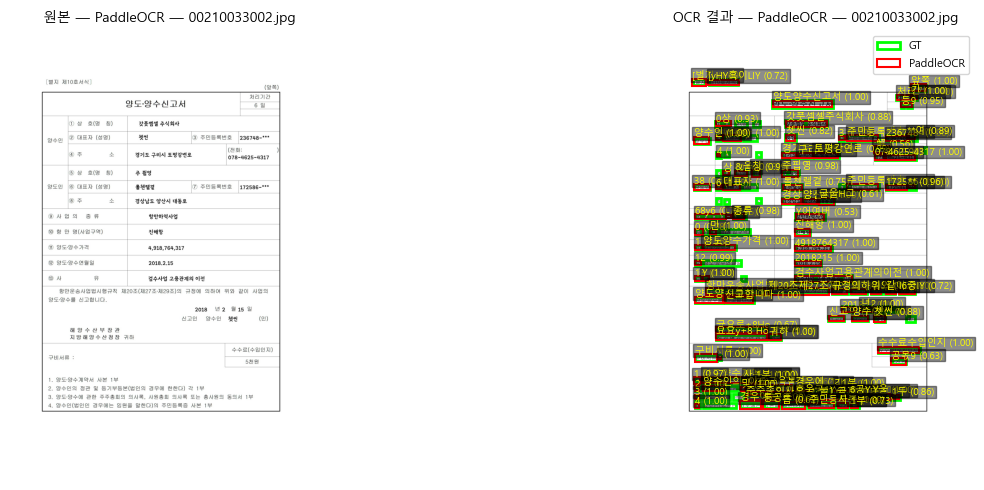

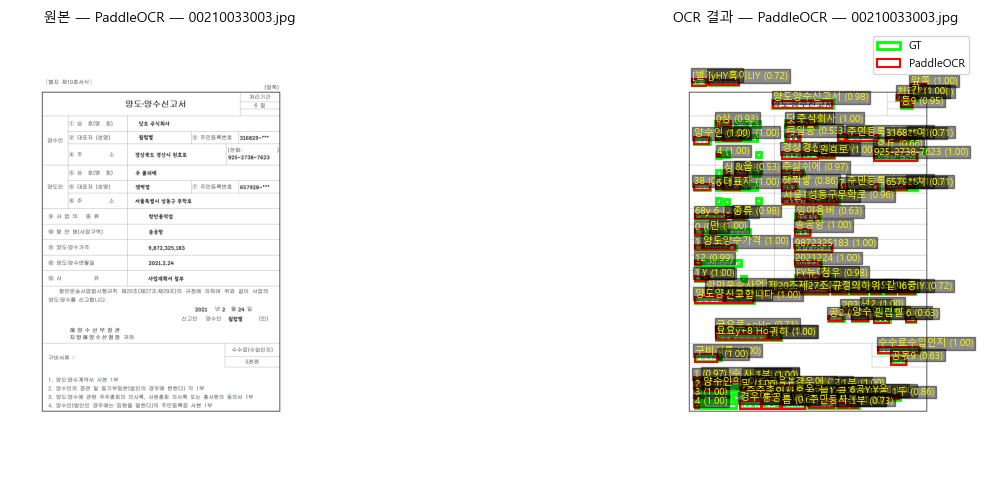

In [8]:
# ── Part 3 보조: 추가 샘플 시각화 ──
# test 2~3번째 이미지 — 원본+OCR 나란히 PNG 저장


for sample in TEST_SAMPLES[1:min(3, len(TEST_SAMPLES))]:  # 0번은 위 셀에서 처리

    img = read_image_bgr(sample.image_path)
    dets = run_paddle_ocr(img, paddle_ocr)
    plot_paddle_ocr_result(
        img, dets,
        f"PaddleOCR — {sample.image_path.name}",
        FIG_DIR / f"03_paddleocr_{sample.image_path.stem}.png",
        gt_boxes=sample.boxes,
    )

> **📖 Part 3 결과 해석**
>
> ### 콘솔 출력
> | 메시지 | 의미 |
> |--------|------|
> | `PaddleOCR 준비 \| lang=korean` | 모델 로드 완료 (GPU/CPU) |
> | `matched= A / B` | GT word B개 중 IoU≥0.5로 PaddleOCR과 **위치 매칭**된 개수 |
> | `CER=0.xxx` | 매칭된 word의 **문자 오류율 평균**. 낮을수록 읽기 정확 |
> | `PaddleOCR regions=N` | 한 장에서 검출+인식된 **텍스트 블록 수** |
>
> ### 시각화 (`03_paddleocr_*.png`) — **좌: 원본 / 우: OCR**
> | 요소 | 의미 |
> |------|------|
> | **좌측** | bbox 없는 **원본 이미지** |
> | **우측 초록** | GT bbox (비교용) |
> | **우측 빨강** | PaddleOCR이 찾은 bbox |
> | **노란 라벨** | `인식텍스트 (confidence)` — confidence 0.5 미만은 코드에서 제외 |
>
> 💡 **CER 0.6~0.8** 도 문서·폰트에 따라 흔합니다. 실무에서는 manifest의 `full_text`와 confidence로 후처리(필터·규칙)합니다.  
> 💡 CPU 추론은 **이미지당 수십 초** 걸릴 수 있습니다. GPU 사용 시 `PADDLE_USE_GPU=True` (CUDA paddlepaddle 필요).


## Part 4 — 통합 OCR 파이프라인 · manifest · IPAD

Part 3 PaddleOCR을 **실행 파이프라인**으로 묶어 JSON·PNG로 저장합니다. 05·03 노트북의 **IPAD 프레임**에도 동일 OCR을 적용할 수 있습니다.

| 단계 | 설명 |
|------|------|
| **run_ocr_pipeline** | 이미지 1장 → detections[] + `full_text` ( `\|` 로 연결) |
| **ocr_manifest.json** | test 샘플 OCR 결과 + Part 2·3 평가 지표 메타데이터 |
| **predictions/*.png** | 원본+OCR 2열 시각화 |
| **IPAD 프레임** | `IPAD_sample.zip` 프레임에 OCR → `ocr_manifest_ipad.json` |

```
이미지 / IPAD 프레임
    ↓
PaddleOCR (det + rec, pretrained)
    ↓
ocr_manifest.json + predictions/*.png
```


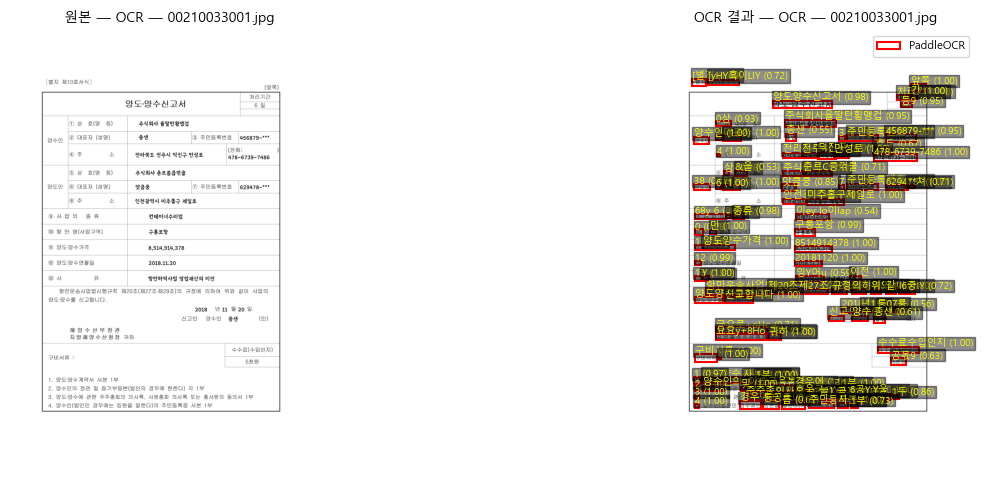

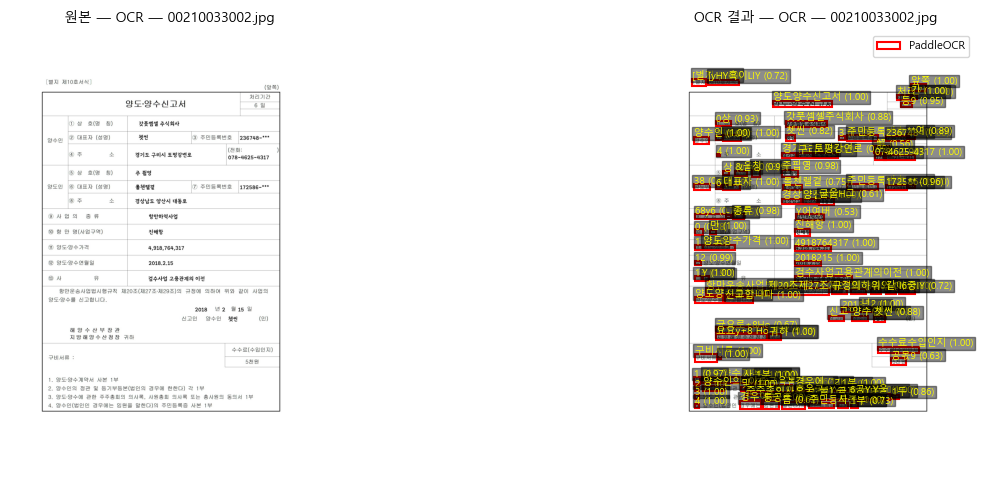

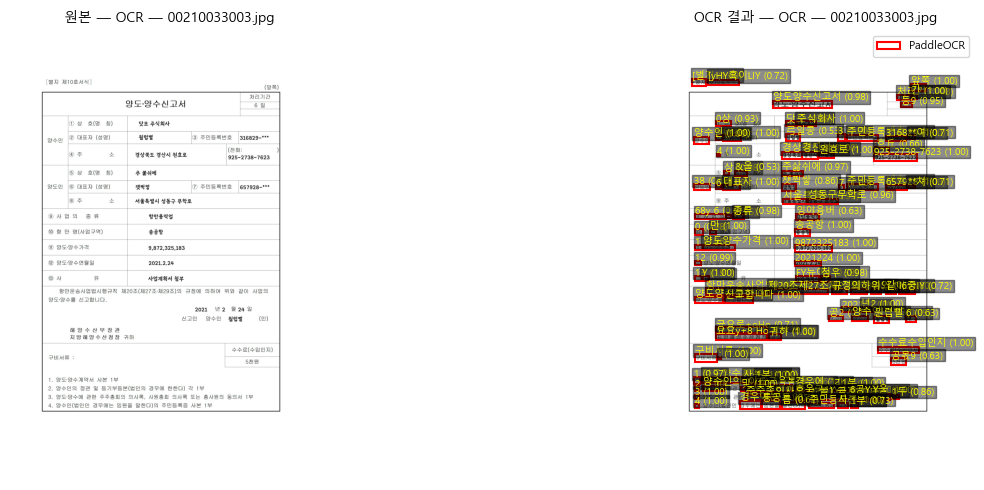

Manifest 저장: output_ocr_kr\ocr_manifest.json
샘플 full_text: [별지 | [yHY흑이LIY | 앞쪽 | 처리기 | 간 | 양도양수신고서 | 등9 | 0상 | 주식회사율딸턴횡맹겁 | 2 | 대표자 | 종샌 | 3 | 주민등록번호 | 456879-*** | 양수인 | :흐丘 | 전라욱도 | 전주시 | 덕진구 | 4 | 만성로 | 478-6739-7486 | 상 | &을 | 주식회사 | 춘르C콩꺾쿨 | 38 | 대표자 | 얏큼쿵 | 7 | 주민등록번호 | 6 | 629478- | **쳐 | 인천광역시 | 미추홀구제일로 | 68y 6 | - | 종류 | 이ey lo이lap | 0 | 만 | 구룡포항 | 1 | 양도양수가격 | 8514914378 | 12 | 20181120 | 13 | Y | 잉Y어u | 이전 | 항만운송사업법시행규칙 | 제20조제27조제29조의 | 규정에 | 의하여 | 위와 | 같이 | I6중IY | 양도양수를 | 신고합니다 | 2018 | 년11 | 릉07룡 | 신고인 | 양수인 | 종샌 | 균요로+oHo | 요요y+8Ho 음IY | 귀하 | 수수료수입인지 | 구비서류 | : | 공몫9 | 양도양수계약서 | 사본 | 1부 | 1 | 2 | 양수인의 | 이丘국음봄I을 | 및 | 경우에 | 각 | 1부 | 3 | 주주총회의 | 의사록 | 흐욱공1Y | 눌1Y6 | 극耳 | 6공Y울 | Y울 | 1두 | 경우에는 | 릉공중 | 4 | 름 | 주민등록증 | 사본 | 1부
[IPAD] 프레임 없음 — IPAD_sample.zip 배치 시 Part 4 영상 OCR 데모 실행


In [10]:
# ── Part 4: 통합 OCR 파이프라인 · manifest · IPAD 프레임 ──
# PaddleOCR 결과를 JSON manifest + PNG로 저장


# 이미지 1장 → detections 리스트 + full_text( | 구분) 반환
def run_ocr_pipeline(
    image_bgr: np.ndarray,
    ocr=None,
    image_path: str = "",
) -> OcrPipelineResult:
    """PaddleOCR 검출+인식 통합 (학습 없음)."""
    dets = run_paddle_ocr(image_bgr, ocr or paddle_ocr)
    # manifest/detection dict 형식으로 정규화
    detections = [
        {
            "bbox": d["bbox"],
            "text_gt": None,
            "text_pred": d["text_pred"],
            "confidence": d["confidence"],
            "source": d["source"],
        }
        for d in dets
    ]
    # 검출된 모든 텍스트를 한 줄로 연결
    full_text = " | ".join(d["text_pred"] for d in detections if d["text_pred"])
    return OcrPipelineResult(
        image_path=image_path,
        detections=detections,
        full_text=full_text,
        method="paddleocr",
    )



# pipeline_results → ocr_manifest.json (ensure_ascii=False로 한글 유지)
def export_ocr_manifest(results: list[OcrPipelineResult], extra: dict | None = None) -> Path:
    """OCR 결과 manifest JSON 저장."""
    payload = {
        "version": "1.0",
        "dataset": "AI_Hub_한글_OCR",
        "engine": "PaddleOCR",
        "paddle_lang": PADDLE_LANG,
        "num_images": len(results),
        "results": [
            {
                "image_path": r.image_path,
                "method": r.method,
                "full_text": r.full_text,
                "detections": r.detections,
            }
            for r in results
        ],
    }
    if extra:
        payload.update(extra)
    MANIFEST_PATH.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    return MANIFEST_PATH



# Part 4용 래퍼 — plot_paddle_ocr_result(원본+OCR 2열) 호출
def plot_ocr_result(result: OcrPipelineResult, image_bgr: np.ndarray, save_path: Path) -> None:
    """인식 결과 bbox + 텍스트 오버레이."""
    plot_paddle_ocr_result(
        image_bgr,
        result.detections,
        f"OCR — {Path(result.image_path).name}",
        save_path,
    )



# IPAD_sample.zip 해제 폴더에서 프레임 jpg/png 경로 수집
def _find_ipad_frames(max_frames: int = 6) -> list[Path]:
    """IPAD_Sample에서 프레임 경로 일부 수집 (05·03 연계)."""
    for base in IPAD_SEARCH_PATHS:
        frames_root = None
        if base.is_dir():
            for sub in base.rglob("*"):
                if sub.is_dir() and sub.name.lower() in ("frames", "frame", "images"):
                    frames_root = sub
                    break
            if frames_root is None:
                frames_root = base
            exts = {".jpg", ".jpeg", ".png", ".bmp"}
            frames = sorted(p for p in frames_root.rglob("*") if p.suffix.lower() in exts)
            if frames:
                return frames[:max_frames]
    return []



# test 샘플 PADDLE_PIPELINE_SAMPLES장 OCR + 시각화
pipeline_results: list[OcrPipelineResult] = []
for sample in TEST_SAMPLES[:PADDLE_PIPELINE_SAMPLES]:  # test 상위 N장 pipeline 데모
    img = read_image_bgr(sample.image_path)
    result = run_ocr_pipeline(img, paddle_ocr, str(sample.image_path))
    pipeline_results.append(result)
    plot_ocr_result(result, img, PRED_DIR / f"ocr_{sample.image_path.stem}.png")

manifest_path = export_ocr_manifest(pipeline_results, extra={
    "detection_metrics_proposal": det_metrics,
    "paddleocr_metrics": paddle_metrics,
})
print(f"Manifest 저장: {manifest_path}")
print("샘플 full_text:", pipeline_results[0].full_text if pipeline_results else "(없음)")


# (선택) 05·03 노트북과 연계 — IPAD 대표 프레임 OCR
if RUN_IPAD_FRAMES:
    ipad_frames = _find_ipad_frames()
    if ipad_frames:
        print(f"\n[IPAD] 프레임 {len(ipad_frames)}장 PaddleOCR 적용")
        ipad_results = []
        for fp in ipad_frames:  # IPAD 프레임별 OCR + PNG
            img = read_image_bgr(fp)
            res = run_ocr_pipeline(img, paddle_ocr, str(fp))
            ipad_results.append(res)
            plot_ocr_result(res, img, PRED_DIR / f"ipad_{fp.stem}.png")
        ipad_manifest = OUTPUT_DIR / "ocr_manifest_ipad.json"  # IPAD 전용 manifest

        payload = {
            "source": "IPAD_frames",
            "engine": "PaddleOCR",
            "results": [
                {"image_path": r.image_path, "full_text": r.full_text, "detections": r.detections}
                for r in ipad_results
            ],
        }
        ipad_manifest.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
        print(f"IPAD OCR manifest: {ipad_manifest}")
    else:
        print("[IPAD] 프레임 없음 — IPAD_sample.zip 배치 시 Part 4 영상 OCR 데모 실행")

In [11]:
# PaddleOCR은 det+rec를 한 번에 수행합니다.
# Part 2 OpenCV proposal F1 vs Part 3 PaddleOCR CER 한 줄 비교

# Morphology proposal(Part 2)과 품질을 비교해 보세요.
print(f"Part 2 proposal F1={det_metrics['f1']:.3f} | Part 3 PaddleOCR CER={paddle_metrics['mean_cer']:.3f}")

Part 2 proposal F1=0.000 | Part 3 PaddleOCR CER=0.627


> **📖 Part 4 결과 해석 (초보자용)**
>
> ### 저장된 산출물
> | 파일/폴더 | 설명 |
> |-----------|------|
> | `output_ocr_kr/ocr_manifest.json` | test 샘플별 bbox·텍스트·confidence |
> | `output_ocr_kr/predictions/ocr_*.png` | AI Hub test 이미지 OCR 시각화 |
> | `output_ocr_kr/predictions/ipad_*.png` | IPAD 프레임 OCR 시각화 (zip 있을 때) |
> | `output_ocr_kr/ocr_manifest_ipad.json` | IPAD 전용 manifest |
>
> ### manifest JSON 구조 (요약)
> ```json
> {
>   "engine": "PaddleOCR",
>   "results": [
>     {
>       "image_path": "...",
>       "full_text": "글자1 | 글자2 | ...",
>       "detections": [
>         {"bbox": [x1,y1,x2,y2], "text_pred": "...", "confidence": 0.95}
>       ]
>     }
>   ]
> }
> ```
>
> 💡 `full_text`는 검출된 모든 문자열을 ` | `로 이은 것입니다. 알람·검색·VLM 프롬프트 입력으로 활용할 수 있습니다.  
> 💡 IPAD 프레임 OCR은 **05 VLM 요약 + 06 OCR** 연계 예시 — "이 장면에 어떤 글자가 보이는가?"를 자동 기록합니다.


---

### 실습 요약

- **Part 1** — AI Hub JSON 라벨 · `AI_Hub_한글_OCR.zip` 로드/시각화
- **Part 2** — Morphology proposal · Polygon IoU · Detection P/R/F1 (베이스라인 비교)
- **Part 3** — **PaddleOCR** pretrained 검출·인식 · GT 대비 CER
- **Part 4** — 통합 OCR 파이프라인 · `ocr_manifest.json` · IPAD 프레임 OCR(선택)

## 한눈에 보는 파이프라인

```
AI_Hub_한글_OCR.zip → AI_Hub_한글_OCR/
        ↓ Part 1: JSON + jpg 매칭, GT 시각화
┌───────────────────────────────────────┐
│  Morphology proposal (Part 2, 비교용)  │
│  PaddleOCR det + rec (Part 3, 실무)   │
└───────────────────────────────────────┘
        ↓ Part 4: manifest + PNG
   ocr_manifest.json · predictions/
        ↓ (선택) IPAD 프레임
   ocr_manifest_ipad.json
```

## 생성된 파일 안내

| 파일 | 내용 |
|------|------|
| `figures/01_train_gt_overlay.png` | Train GT bbox + 텍스트 |
| `figures/01_test_gt_overlay.png` | Test GT bbox + 텍스트 |
| `figures/02_detection_proposal.png` | GT vs OpenCV proposal |
| `figures/03_paddleocr_*.png` | 원본 + PaddleOCR (좌/우) |
| `predictions/ocr_*.png` | Part 4 test OCR 결과 |
| `predictions/ipad_*.png` | IPAD 프레임 OCR |
| `ocr_manifest.json` | OCR JSON 결과 |
| `ocr_manifest_ipad.json` | IPAD OCR JSON |

| 산출물 | 경로 |
|--------|------|
| GT/Detection/PaddleOCR 그래프 | `output_ocr_kr/figures/` |
| OCR manifest | `output_ocr_kr/ocr_manifest.json` |

## 자주 묻는 질문 (FAQ)

**Q. `ModuleNotFoundError: paddleocr`가 나요.**  
A. 노트북 **커널 Python**에 설치하세요: `import sys; !{sys.executable} -m pip install paddlepaddle==2.6.2 paddleocr==2.9.1` 후 **커널 재시작**.

**Q. zip 풀 때 폴더명이 `╣┤≤...` 로 깨져요.**  
A. Windows CP949 파일명 문제입니다. `_extract_aihub_zip`이 cp949 복원하며 `AI_Hub_한글_OCR/`에만 풉니다. 깨진 폴더는 삭제 후 셀 재실행.

**Q. Part 2 F1=0 인데 실패인가요?**  
A. Morphology baseline 한계입니다. Part 3 PaddleOCR 결과를 보세요.

**Q. OCR이 너무 느려요.**  
A. CPU는 이미지당 수십 초~수 분. GPU paddlepaddle 설치 후 `PADDLE_USE_GPU=True`, 또는 `PADDLE_MAX_OCR_SAMPLES`·`PADDLE_PIPELINE_SAMPLES` 줄이기.

**Q. 05 VLM 요약과 OCR 차이는?**  
A. VLM은 **자연어 요약**("장면 설명"), OCR은 **정확한 문자열+좌표**. 표·HMI·라벨 읽기는 OCR이 적합.

### 참고

- AI Hub — [야외 실제 촬영 한글 이미지](https://aihub.or.kr)
- [PaddleOCR](https://github.com/PaddlePaddle/PaddleOCR) — 한글 `lang=korean`

> **다음 단계:** `07` 키포인트 탐지 · `08` 통합 manifest
